In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("Powerplant dataset.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


#AT =>temperature
#V =>vaccum
#Ap =>Presssure
#RH => Humidity
#PE =>produced energy

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
#Model train
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [10]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [11]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [12]:
type(X_train_scaled)

numpy.ndarray

In [13]:
type(y_train)
y_train.shape

(7654,)

In [14]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [15]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

Buildd ANN Model

In [16]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            #1 hideden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            
            #2 hideden layer
            nn.Linear(6,6), 
            nn.ReLU(),

            #3 hideden layer
            nn.Linear(6,1)
        )   

    def forward(self,x):
        return self.model(x)

In [ ]:
import torch.optim as optim

model= ANN()

#loss,optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [18]:
#train the ann
train_losses=[]
val_losses=[]
epochs=100
best_val_loss=float("inf")

for epoch in range(epochs):
    model.train()
    running_loss=0.0    
    
    for xb,yb in train_loader:
        
        optimizer.zero_grad()
        
        outputs=model(xb)
        loss=crietrion(outputs,yb)
        loss.backward()  
        optimizer.step()

        running_loss+=loss.item()

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

#Validation
    model.eval()
    running_val_loss=0.0    
    
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch ${epoch+1}/{epochs} ==> Train Loss = {epoch_train_loss} & Val Loss = {epoch_val_loss}")

    if  epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")


Epoch $1/100 ==> Train Loss = 205454.26744791667 & Val Loss = 203152.25
Epoch $2/100 ==> Train Loss = 195491.65592447916 & Val Loss = 182881.890625
Epoch $3/100 ==> Train Loss = 161161.61689453124 & Val Loss = 136935.40625
Epoch $4/100 ==> Train Loss = 111871.15888671875 & Val Loss = 89713.125
Epoch $5/100 ==> Train Loss = 71779.933984375 & Val Loss = 56716.7734375
Epoch $6/100 ==> Train Loss = 43280.24596354167 & Val Loss = 31644.998046875
Epoch $7/100 ==> Train Loss = 22342.065795898438 & Val Loss = 14915.943359375
Epoch $8/100 ==> Train Loss = 10425.25830485026 & Val Loss = 7250.4130859375
Epoch $9/100 ==> Train Loss = 5567.78332417806 & Val Loss = 4357.47021484375
Epoch $10/100 ==> Train Loss = 3558.0736704508463 & Val Loss = 2949.138916015625
Epoch $11/100 ==> Train Loss = 2415.9420405069986 & Val Loss = 2049.817138671875
Epoch $12/100 ==> Train Loss = 1688.9106157938638 & Val Loss = 1455.5379638671875
Epoch $13/100 ==> Train Loss = 1187.5262935638427 & Val Loss = 1047.68322753906

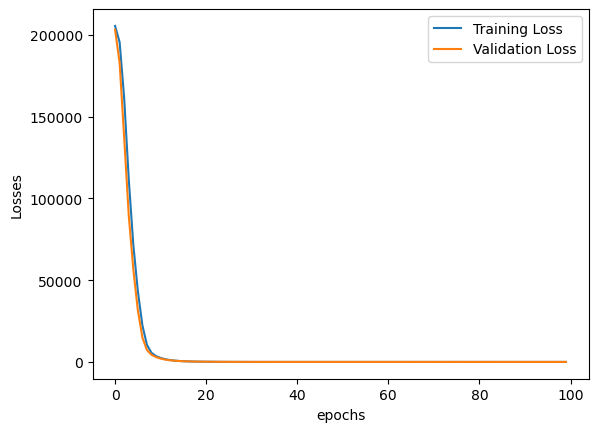

In [19]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({"Training Loss": train_losses, "Validation Loss": val_losses})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("epochs")
plt.ylabel("Losses")

plt.legend()

In [20]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
#Evaluation

model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.268707275390625
Testing MSE: 18.563888549804688


In [22]:
from sklearn.metrics import r2_score

print("r2 score=",r2_score(y_test,test_preds))


r2 score= 0.9351240060326169


In [23]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.624969,433.27
1,436.687927,438.16
2,462.028839,458.42
3,477.313812,480.82
4,435.268188,441.41
...,...,...
1909,451.281464,456.70
1910,431.174896,438.04
1911,467.542145,467.80
1912,430.659668,437.14
